In [375]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

In [376]:
df=pd.read_csv(r'signal_metrics_with_sigQUAL.csv')

DATA INSPECTION

In [377]:
df

,Timestamp,Locality,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),Network Type,BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
0,50:40.0,Anisabad,25.599109,85.137355,-84.274113,47,1.863890,129.122914,3G,0.000000,0.000000,0.000000
1,18:44.9,Boring Road,25.564499,85.088607,-84.643065,58,1.567842,130.536386,3G,0.000000,0.000000,0.000000
2,34:20.9,Rajendra Nagar,25.698981,85.193941,-79.656127,45,1.116387,191.521373,3G,0.000000,0.000000,0.000000
3,40:35.4,Gandhi Maidan,25.470778,85.106450,-85.607373,47,2.171551,194.023024,3G,0.000000,0.000000,0.000000
4,05:33.0,Kumhrar,25.573279,85.158042,-83.978154,44,1.753478,174.957830,3G,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
16824,10:04.6,Ashok Rajpath,25.513184,85.297269,-98.074638,90,1.315881,182.367525,LTE,-98.921721,-107.391454,-98.493889
16825,16:19.1,Danapur,25.706732,85.112217,-90.221943,88,1.034086,184.187310,LTE,-92.392586,-96.749804,-92.434660
16826,22:33.5,Kumhrar,25.706064,85.262218,-88.158025,74,2.473377,179.894750,LTE,-83.235642,-95.165784,-88.222760
16827,47:31.2,Boring Canal Road,25.724624,85.233365,-87.579509,73,2.117080,134.458401,LTE,-87.694985,-92.616868,-84.749607


In [378]:
df.columns

Index(['Timestamp', 'Locality', 'Latitude', 'Longitude',
       'Signal Strength (dBm)', 'Signal Quality (%)', 'Data Throughput (Mbps)',
       'Latency (ms)', 'Network Type', 'BB60C Measurement (dBm)',
       'srsRAN Measurement (dBm)', 'BladeRFxA9 Measurement (dBm)'],
      dtype='str')

In [379]:
# Column name constants

LONGITUDE = "Longitude"
LATITUDE = "Latitude"
NETWORK = "Network Type"
SIGNAL = "Signal Strength (dBm)"
SIGNAL_QUALITY = "Signal Quality (%)"
THROUGHPUT = "Data Throughput (Mbps)"
LATENCY = "Latency (ms)"
BB60C = "BB60C Measurement (dBm)"
SRSRAN = "srsRAN Measurement (dBm)"
BLADERF = "BladeRFxA9 Measurement (dBm)"

cols = [LONGITUDE,LATITUDE,NETWORK,SIGNAL,SIGNAL_QUALITY,THROUGHPUT,LATENCY,BB60C,SRSRAN,BLADERF]

# ORDER = ["3G", "4G", "5G"]
ORDER = ["5G"]

PALETTE = {
    "3G": "lightgreen",
    "4G": "skyblue",
    "LTE": "red",
    "5G": "lightcoral"
}

METRICS = [
    SIGNAL,
    SIGNAL_QUALITY,
    THROUGHPUT,
    LATENCY,
    BB60C,
    SRSRAN,
    BLADERF
]


In [380]:
# column dtypes

df[cols].dtypes

Longitude                       float64
Latitude                        float64
Network Type                        str
Signal Strength (dBm)           float64
Signal Quality (%)                int64
Data Throughput (Mbps)          float64
Latency (ms)                    float64
BB60C Measurement (dBm)         float64
srsRAN Measurement (dBm)        float64
BladeRFxA9 Measurement (dBm)    float64
dtype: object

In [381]:
# memory usage

df[cols].memory_usage(deep=True)

Index                              132
Longitude                       134632
Latitude                        134632
Network Type                    862503
Signal Strength (dBm)           134632
Signal Quality (%)              134632
Data Throughput (Mbps)          134632
Latency (ms)                    134632
BB60C Measurement (dBm)         134632
srsRAN Measurement (dBm)        134632
BladeRFxA9 Measurement (dBm)    134632
dtype: int64

In [382]:
# total memory usage
df[cols].memory_usage(deep=True).sum()

np.int64(2074323)

In [383]:
# examining min and max 

(df
[cols]
.select_dtypes(float)
.describe()
)

,Longitude,Latitude,Signal Strength (dBm),Data Throughput (Mbps),Latency (ms),BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
count,16829.000000,16829.000000,16829.000000,16829.000000,16829.000000,16829.000000,16829.000000,16829.000000
mean,85.137314,25.594796,-90.072484,16.182856,101.313624,-68.820150,-74.439562,-68.819930
std,0.090095,0.089881,5.399368,25.702734,56.010418,40.046739,43.215204,39.996934
min,84.957936,25.414575,-116.942267,1.000423,10.019527,-115.667514,-124.652054,-119.207545
25%,85.064124,25.522858,-93.615962,2.001749,50.320775,-94.021959,-101.249987,-93.749032
50%,85.138149,25.595383,-89.665566,2.997175,100.264318,-89.126942,-96.838442,-89.282746
75%,85.209504,25.667620,-86.145491,9.956314,149.951112,0.000000,0.000000,0.000000
max,85.316994,25.773648,-74.644848,99.985831,199.991081,0.000000,0.000000,0.000000


In [384]:
# # converting float64 to float16 
# (df[cols]
#  .select_dtypes(float)
#  .astype('float16')
# )

KPI ANALYSIS

<Axes: xlabel='Network Type', ylabel='Latency (ms)'>

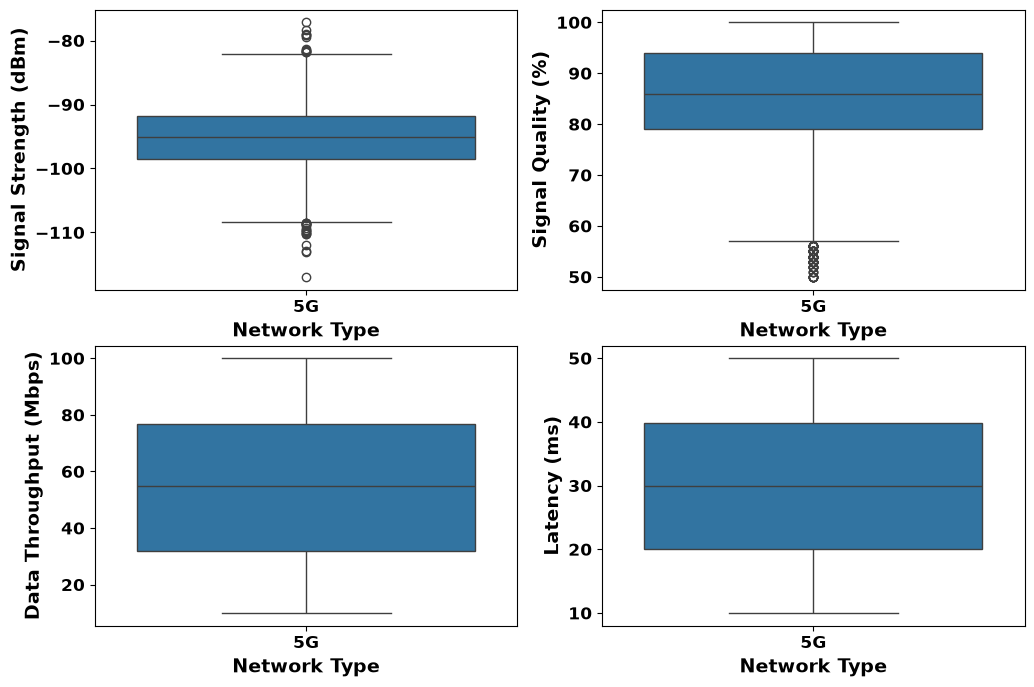

In [385]:
# Boxplots for KPIs

df_5G = df[df[NETWORK]=="5G"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes_flat = axes.flatten()

sns.boxplot(data=df_5G, x= df_5G[NETWORK], y= SIGNAL, hue= df_5G[NETWORK], ax= axes_flat[0])
sns.boxplot(data=df_5G, x= df_5G[NETWORK], y= SIGNAL_QUALITY, hue= df_5G[NETWORK], ax= axes_flat[1])
sns.boxplot(data=df_5G, x= df_5G[NETWORK], y= THROUGHPUT, hue= df_5G[NETWORK], ax= axes_flat[2])
sns.boxplot(data=df_5G, x= df_5G[NETWORK], y= LATENCY, hue= df_5G[NETWORK], ax= axes_flat[3])



In [386]:
# df_5G.head()

In [387]:
# Categories of Signal Strength

#Thresholds for KPIs
SIGNAL_STR_EXCELLENT_5G = -80 #dBm
SIGNAL_STR_GOOD_5G = -90
SIGNAL_STR_FAIR_5G = -100
SIGNAL_STR_POOR_5G = -110

def classify_signal_strength(score):
    if score >= SIGNAL_STR_EXCELLENT_5G:
        return "Excellent"
    elif score >= SIGNAL_STR_GOOD_5G:
        return "Good"
    elif score >= SIGNAL_STR_FAIR_5G:
        return "Fair"
    elif score >= SIGNAL_STR_POOR_5G:
        return "Poor"
    else:
        return "Very Poor"


df_5G["Signal Strength Ratings"] = df_5G[SIGNAL].apply(classify_signal_strength)

# Preview result
#df_5G.head()

In [388]:
# Ratings of Signal Strength

SIGNAL_QUAL_EXCELLENT_5G = 80 # percent
SIGNAL_QUAL_GOOD_5G = 65
SIGNAL_QUAL_FAIR_5G = 50
SIGNAL_QUAL_POOR_5G = 30

def classify_signal_quality(score):
    if score >= SIGNAL_QUAL_EXCELLENT_5G:
        return "Excellent"
    elif score >= SIGNAL_QUAL_GOOD_5G:
        return "Good"
    elif score >= SIGNAL_QUAL_FAIR_5G:
        return "Fair"
    elif score >= SIGNAL_QUAL_POOR_5G:
        return "Poor"
    else:
        return "Very Poor"


df_5G["Signal Quality Ratings"] = df_5G[SIGNAL_QUALITY].apply(classify_signal_quality)

# Preview result
#df_5G.head()

In [389]:
# Ratings of 5G Throughput

THROUGHPUT_EXCELLENT_5G = 200 #Mbps
THROUGHPUT_GOOD_5G = 100
THROUGHPUT_FAIR_5G = 50
THROUGHPUT_POOR_5G = 10

def classify_throughput(score):
    if score >= THROUGHPUT_EXCELLENT_5G:
        return "Excellent"
    elif score >= THROUGHPUT_GOOD_5G:
        return "Good"
    elif score >= THROUGHPUT_FAIR_5G:
        return "Fair"
    elif score >= THROUGHPUT_POOR_5G:
        return "Poor"
    else:
        return "Very Poor"


df_5G["Throughput Ratings"] = df_5G[THROUGHPUT].apply(classify_signal_quality)

# Preview result
#df_5G.head()

In [390]:
# Ratings of 5G Latency

LATENCY_EXCELLENT_5G = 20 #ms
LATENCY_GOOD_5G = 40
LATENCY_FAIR_5G = 70
LATENCY_POOR_5G = 120

def classify_Latency(score):
    if score <= LATENCY_EXCELLENT_5G:
        return "Excellent"
    elif score <= LATENCY_GOOD_5G:
        return "Good"
    elif score <= LATENCY_FAIR_5G:
        return "Fair"
    elif score <= LATENCY_POOR_5G:
        return "Poor"
    else:
        return "Very Poor"


df_5G["Latency Ratings"] = df_5G[LATENCY].apply(classify_Latency)

# Preview result
df_5G.head()

,Timestamp,Locality,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),Network Type,BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm),Signal Strength Ratings,Signal Quality Ratings,Throughput Ratings,Latency Ratings
8427,00:01.6,Danapur,25.735138,85.208400,-94.143159,88,68.596932,46.598387,5G,-90.642773,-101.895905,-96.570698,Fair,Excellent,Good,Fair
8428,03:08.8,Phulwari Sharif,25.538556,85.159860,-94.564765,96,38.292038,30.342828,5G,-90.489100,-103.318303,-95.102467,Fair,Excellent,Poor,Good
8429,37:28.2,Bailey Road,25.682170,85.194898,-98.387078,85,13.665592,44.218423,5G,-96.350500,-106.016209,-100.800073,Fair,Excellent,Very Poor,Fair
8430,43:42.6,Rajendra Nagar,25.650772,85.144117,-94.695517,60,65.642850,23.462169,5G,-93.138291,-102.768534,-93.605835,Fair,Fair,Good,Good
8431,46:49.8,S.K. Puri,25.473737,85.075388,-103.938358,72,79.877166,23.632142,5G,-99.630785,-109.646294,-104.364394,Poor,Good,Good,Good


In [391]:
# KPI issue classifcation

def troubleshoot(row):
    # Weak signal + low throughput
    if row[SIGNAL] < SIGNAL_STR_POOR_5G and row[THROUGHPUT] < THROUGHPUT_POOR_5G:
        return "Coverage degradation", "Review antenna coverage, power, or tilt"

    # Acceptable signal + low throughput
    elif row[SIGNAL] >= SIGNAL_STR_POOR_5G and row[THROUGHPUT] < THROUGHPUT_POOR_5G:
        return "Possible capacity/interference issue", "Review utilization, SINR, and RSRQ"

    
    # Good signal + high latency
    elif row[SIGNAL] >= SIGNAL_STR_POOR_5G and row[LATENCY] > LATENCY_POOR_5G:
        return "Possible transport/core issue", "Escalate for transport/core investigation"

    
    return "No issue detected", "No action required"


df_5G[["Issue", "Recommendation"]] = df_5G.apply(
    troubleshoot, axis=1, result_type="expand"
)

# df_5G.head()


In [392]:
# QoE dataframe

df_qoe = df[df[NETWORK].isin(ORDER)].copy()

In [393]:
#df_qoe.head()

In [394]:
# Normalizing data for Qality of Experience

def minmax_normalize(series, higher_is_better=True):
    """
    Normalized 0–1.
    If higher_is_better=False, lower raw values receive higher normalized scores.
    """
    series = pd.to_numeric(series, errors="coerce")

    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series(1.0, index=series.index)

    normalized = (series - min_val) / (max_val - min_val)

    if not higher_is_better:
        normalized = 1 - normalized

    return normalized

In [395]:
# Normalize KPIs

df_5G["norm_signal"] = minmax_normalize(
    df_5G[SIGNAL],
    higher_is_better=True
)

df_5G["norm_signal_quality"] = minmax_normalize(
    df_5G[SIGNAL_QUALITY],
    higher_is_better=True
)

df_5G["norm_throughput"] = minmax_normalize(
    df_5G[THROUGHPUT],
    higher_is_better=True
)

df_5G["norm_latency"] = minmax_normalize(
    df_5G[LATENCY],
    higher_is_better=False
)

df_5G["norm_latency"] = minmax_normalize(
    df_5G[LATENCY],
    higher_is_better=False
)

# Radio Quality Index
df_5G["QoE Index"] = (
    0.25 * df_5G["norm_signal_quality"] +
    0.2 * df_5G["norm_signal"]+ 
    0.35 * df_5G["norm_throughput"] +
    0.2 * df_5G["norm_latency"]
)



df_5G["QoE_percent"] = df_5G["QoE Index"] * 100

#df_5G.head()

In [396]:
# Definition of QoE Ratings

def classify_qoe(score):
    if score >= 90:
        return "Excellent"
    elif score >= 80:
        return "Very Good"
    elif score >= 60:
        return "Good"
    elif score >= 40:
        return "Fair"
    else:
        return "Poor"


df_5G["QoE_rating"] = df_5G["QoE_percent"].apply(classify_qoe)

# Preview result
# df_5G.columns

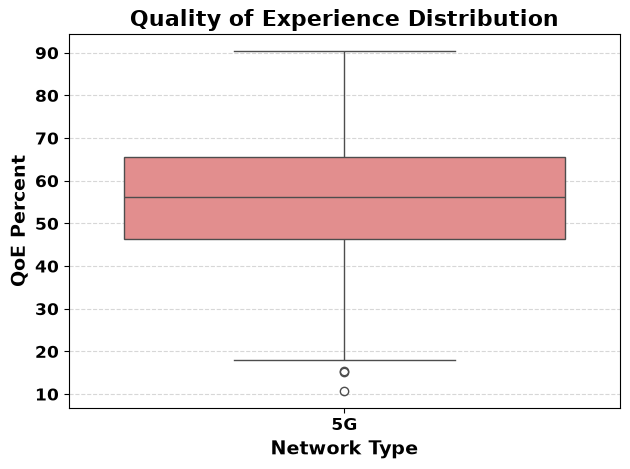

In [397]:
# Distribution of QoE % values
ax = sns.boxplot(
    data = df_5G,
    x = df[NETWORK],
    y = "QoE_percent",
    hue = df[NETWORK],
    order = ORDER,
    palette= PALETTE,
    legend=False,
)

# QOE_METRICS = [QOE_PERCENT]

# boxplot_stats = compute_boxplot_stats(
#     data=df_qoe,
#     group_col=NETWORK,
#     metrics= QOE_METRICS
# )

plt.title(f"Quality of Experience Distribution")
plt.xlabel("Network Type")
plt.ylabel("QoE Percent")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


QOE HEATMAPS

In [398]:
# Map QoE ratings to numerical values

qoe_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very Good": 4,
    "Excellent": 5
}

# # Custom Ericsson-style color progression
cmap = ListedColormap([
    "#d73027",   # Poor - Red
    "#ffffff",   # Fair - Orange
    "#fffffff8",   # Good - Yellow
    "#ffffff",   # Very Good - Light Green
    "#FFFFFF"    # Excellent - Green
])

 
df_5G["QoE_numeric"] = df_5G["QoE_rating"].map(qoe_map)

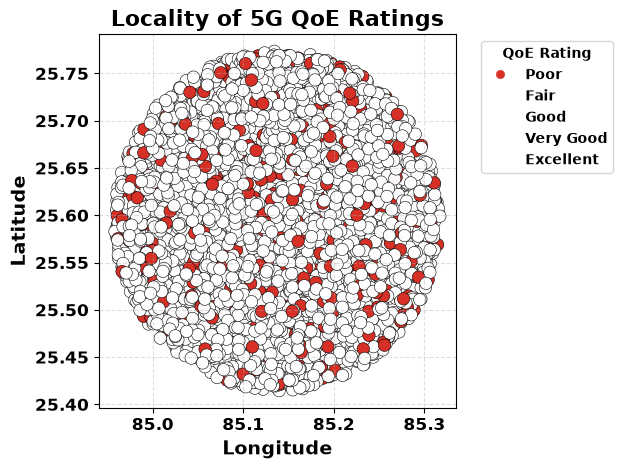

In [399]:
# Locality of 5G QoE ratings

# plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    x = df_5G[LONGITUDE],
    y = df_5G[LATITUDE],
    s=80,
    c = df_5G["QoE_numeric"],
    cmap = cmap,
    edgecolor="black",
    linewidth=0.4,
    label= "RATING"
)

# cbar = plt.colorbar(scatter)
# cbar.set_label(f"QoE Rating")

plt.title(f"Locality of 5G QoE Ratings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

handles, _ = scatter.legend_elements()
plt.legend(handles=handles, labels=["Poor", "Fair", "Good", "Very Good", "Excellent"], title="QoE Rating", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

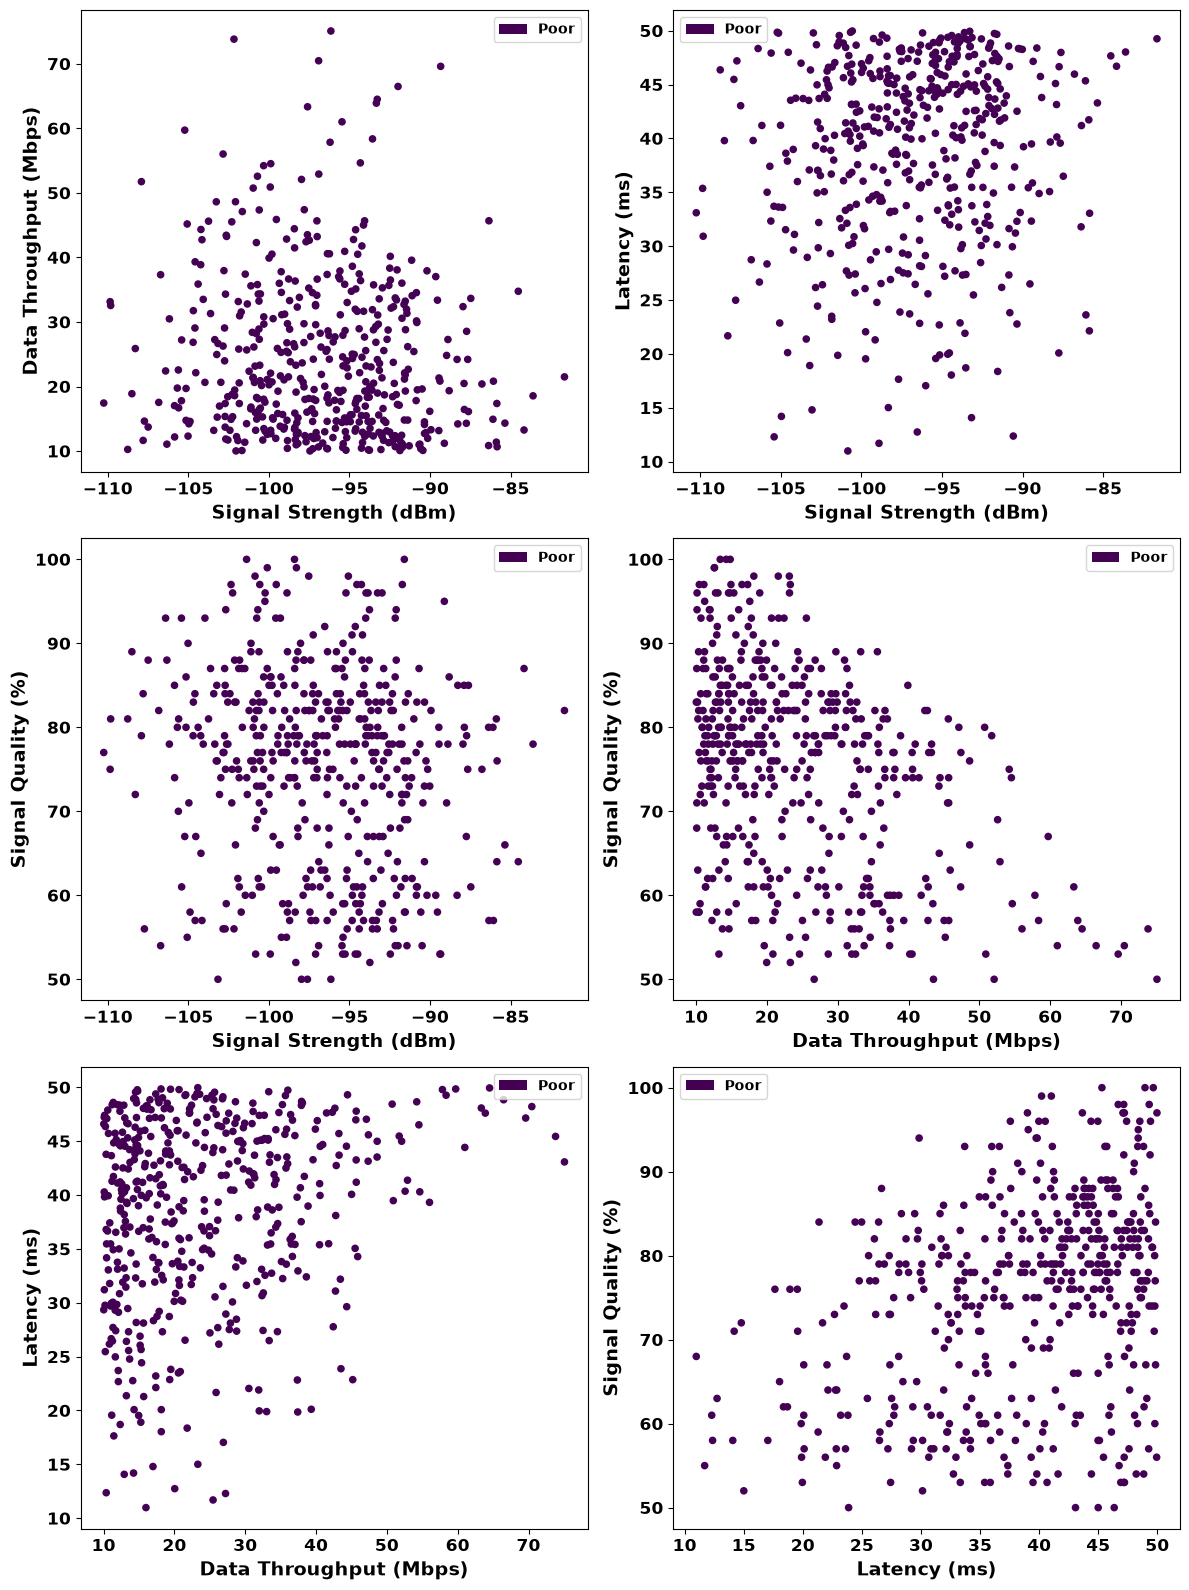

In [400]:
Poor_5G = df_5G[df_5G["QoE_rating"] == "Poor"]

plt.rcParams['axes.labelsize'] = 14       # Font size for X and Y labels
plt.rcParams['axes.labelweight'] = 'bold' # Bold X and Y labels
plt.rcParams['axes.titlesize'] = 16       # Font size for subplot titles
plt.rcParams['axes.titleweight'] = 'bold' # Bold subplot titles
plt.rcParams['xtick.labelsize'] = 12      # Font size for X tick values
plt.rcParams['ytick.labelsize'] = 12      # Font size for Y tick values

plt.rcParams['font.weight'] = 'bold'

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 16))

axes_flat = axes.flatten()

Poor_5G.plot.scatter(x=SIGNAL, y=THROUGHPUT, c="QoE_rating", ax=axes_flat[0])
Poor_5G.plot.scatter(x=SIGNAL, y=LATENCY, c="QoE_rating", ax=axes_flat[1])
Poor_5G.plot.scatter(x=SIGNAL, y=SIGNAL_QUALITY, c="QoE_rating", ax=axes_flat[2])
Poor_5G.plot.scatter(x=THROUGHPUT, y=SIGNAL_QUALITY, c="QoE_rating", ax=axes_flat[3])
Poor_5G.plot.scatter(x=THROUGHPUT, y=LATENCY, c="QoE_rating", ax=axes_flat[4])
Poor_5G.plot.scatter(x=LATENCY, y=SIGNAL_QUALITY, c="QoE_rating", ax=axes_flat[5])

plt.tight_layout()
plt.show()


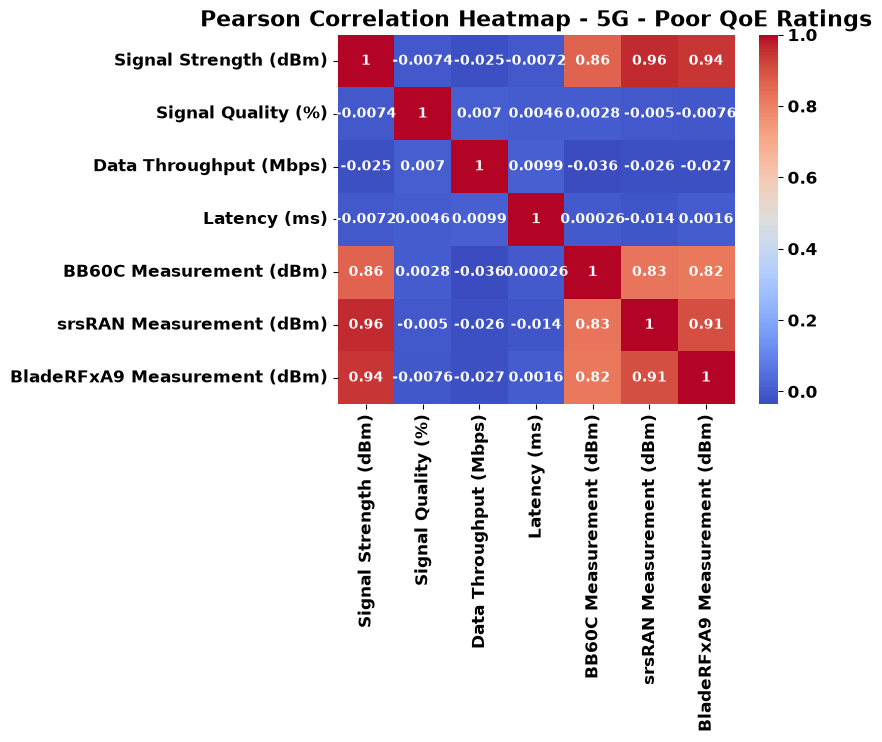

In [401]:
pearson_corr =df.loc[df[NETWORK]=="5G", [SIGNAL, SIGNAL_QUALITY, THROUGHPUT, LATENCY, BB60C, SRSRAN, BLADERF]].corr(method='pearson')


sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap - 5G - Poor QoE Ratings")
plt.show()

In [402]:
df_5G.to_csv("df_5G_powerbi.csv", index=False)

output_file = Path("outputs/5G_powerBI.csv")
output_file.parent.mkdir(parents=True, exist_ok=True)
print(Path.cwd())
print(output_file.resolve())

df_5G.to_csv(output_file, index=False)

g:\My Drive\7 RF project\network analysis Python files
G:\My Drive\7 RF project\network analysis Python files\outputs\5G_powerBI.csv
